# AI-Powered Fake News Detectiion using Text Classification

<!-- just for my own reference -->

## Algorithms Used

- Logistic Regression (Parametric)
- K-Nearest Neighbors (Non-Parametric)
- Random Forest (Ensemble)
- Feedforward Neural Networks (Deep Learning)

## Dataset

The dataset used for this project is the "Fake News" dataset available on Kaggle.
Link to the dataset: [Fake News Dataset](https://www.kaggle.com/datasets/algord/fake-news/data)

## Dataset Information

Required columns in the dataset:

- `title`: The title of the news article.
- `source_domain`: The domain of the news source.
- `tweet_num`: The number of retweets for the news article.
- `real`: A binary label indicating whether the news is real (1) or fake (0).


In [ ]:
# Importing libraries
import os
import kagglehub

import numpy as np
import pandas as pd

In [ ]:
from google.colab import userdata
userdata.get('KAGGLE_API_TOKEN')

'KGAT_d8edd7d62672ec6c5f6299b03d4a86b6'

In [ ]:
path = kagglehub.dataset_download("algord/fake-news")
print("\nPath to dataset files:", path)

Using Colab cache for faster access to the 'fake-news' dataset.

Path to dataset files: /kaggle/input/fake-news


### Data Wrangling
This section includes cleaning of the data in the following ways:

- Dropping irrelevant columns like `news_url`.
- Dropping null entries.
- Checking incorrect dtypes and converting to correct ones.
- Dropping entries with duplicate `title`.
- Dropping outliers from `tweet_num` as most entries have retweets < 500.

In [ ]:
df = pd.read_csv(f"{path}/FakeNewsNet.csv")
display(df.head())

news = df.copy()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [ ]:
# Dropping irrelevant columns
news = news.drop(columns = ['news_url'])

In [ ]:
# Dropping null values
print("\nNull Entries: ")
print(news.isnull().sum())

news = news.dropna() # removes 330 entries with null source_domain values

print("\nAfter dropping null entries: ")
print(news.isnull().sum())


Null Entries: 
title              0
source_domain    330
tweet_num          0
real               0
dtype: int64

After dropping null entries: 
title            0
source_domain    0
tweet_num        0
real             0
dtype: int64


In [ ]:
# Checking incorrect data types
print(f"Original 'tweet_num' dtype: {news['tweet_num'].dtype}")
print(f"Original 'real' dtype: {news['real'].dtype}")

print("No conversion required.")

Original 'tweet_num' dtype: int64
Original 'real' dtype: int64
No conversion required.


In [ ]:
# Dropping duplicate entries
print(f"Duplicate Entries: {news['title'].duplicated().sum()}")
news = news.drop_duplicates(subset = ['title'])
print(f"After removing duplicate Entries: {news['title'].duplicated().sum()}")

Duplicate Entries: 1468
After removing duplicate Entries: 0


In [ ]:
# Dropping outliers
print(f"Entries with retweets greater than 500: {news[news['tweet_num']>500].value_counts().sum()}")
news = news[news['tweet_num']<=500]

Entries with retweets greater than 500: 576


In [ ]:
print("Final Dataset:")
display(news.sample(10))

print("\nOG Dataset:")
display(df.sample(5))

Final Dataset:


,title,source_domain,tweet_num,real
23144,Fuller House season 3 trailer hits us with all...,hiddenremote.com,33,1
9970,"Prince Harry, Meghan Markle Were ‘Exhausted’ i...",www.usmagazine.com,4,0
2498,Is Katie Holmes Married to Jamie Foxx?,www.brides.com,7,0
8870,Lindsay Lohan once again sparks rumours of con...,tribune.com.pk,15,0
16777,Here's What It's Like to Spend 24 Hours With C...,www.inglewoodtoday.com,24,1
6124,Kim and Kourtney Kardashian Are Halloween Goal...,people.com,47,1
8079,How Paris Hilton Honored 'The Simple Life' on ...,toofab.com,49,1
16343,"Bachelor in Paradise, Cast, Characters and Stars",abc.go.com,47,1
7895,Kylie Jenner and Travis Scott Take a Baby Duty...,feedbox.com,73,1
12852,Nicki Minaj offers to pay students’ tuition af...,www.theguardian.com,78,1



OG Dataset:


,title,news_url,source_domain,tweet_num,real
7744,Did Katy Perry & Orlando Bloom Elope In Prague...,hollywoodlife.com/2018/03/08/are-katy-perry-or...,hollywoodlife.com,22,0
1503,"TVLine Items: Dove's S.H.I.E.L.D. Role, Twilig...",https://tvline.com/2018/01/29/agents-of-shield...,tvline.com,60,1
6580,Sandra Bullock Is Not Married to Boyfriend Bry...,https://people.com/movies/sandra-bullock-is-no...,people.com,15,1
16214,John Legend and Chrissy Teigen Pitching Daytim...,gossipthot.wordpress.com/2017/01/26/john-legen...,gossipthot.wordpress.com,8,0
1682,"‘I thought I was going to die’: In statement, ...",https://www.washingtonpost.com/news/early-lead...,www.washingtonpost.com,51,1


### Exploratory Data Analysis
This section includes exploring the distribution of the dataset using charts (matplotlib)
- Distribution of `real` using bar graph & pie chart
- Histogram of `tweet_num`
- WordCloud of Real and Fake news
- Correlation Analysis of `tweet_num` and `real`

In [ ]:
# Importing libraries
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

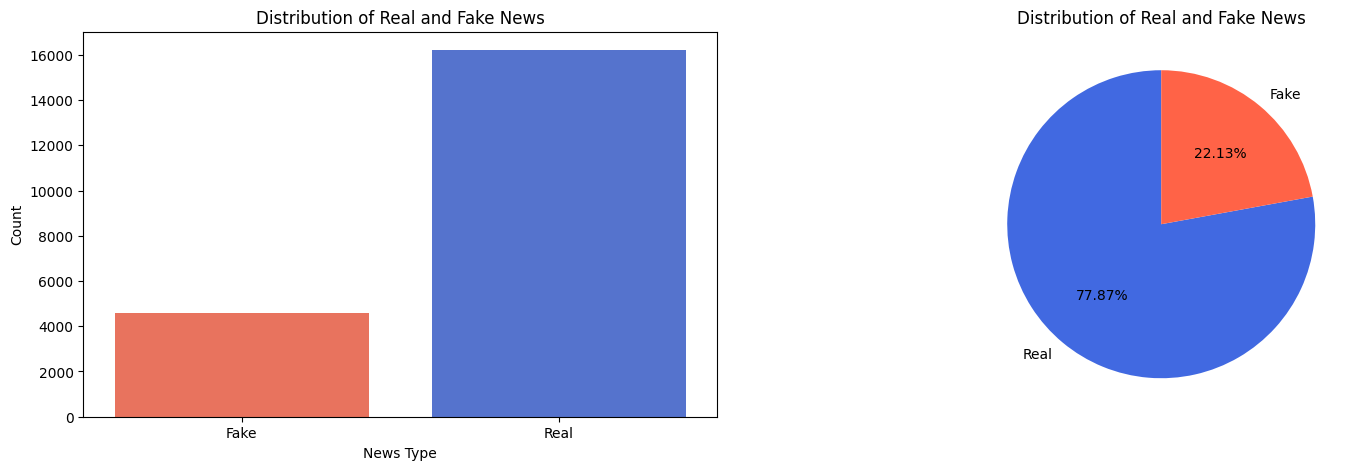


No. of fake news: 4607
No. of real news: 16215


In [ ]:
# Distribution of News Type (Real or Fake)
plt.figure(figsize=(18,5))
plt.subplot(1, 2, 1)
sns.countplot(data=news, x='real', hue='real', palette=['tomato','royalblue'], legend=False)
plt.xticks([0,1],['Fake','Real'])
plt.title('Distribution of Real and Fake News')
plt.xlabel('News Type')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.pie(news['real'].value_counts(), labels=['Real', 'Fake'], startangle=90, autopct='%1.2f%%', colors=['royalblue','tomato'])
plt.title('Distribution of Real and Fake News')

plt.show()
print(f"\nNo. of fake news: {news[news['real'] == 0].value_counts().sum()}")
print(f"No. of real news: {news[news['real'] == 1].value_counts().sum()}")

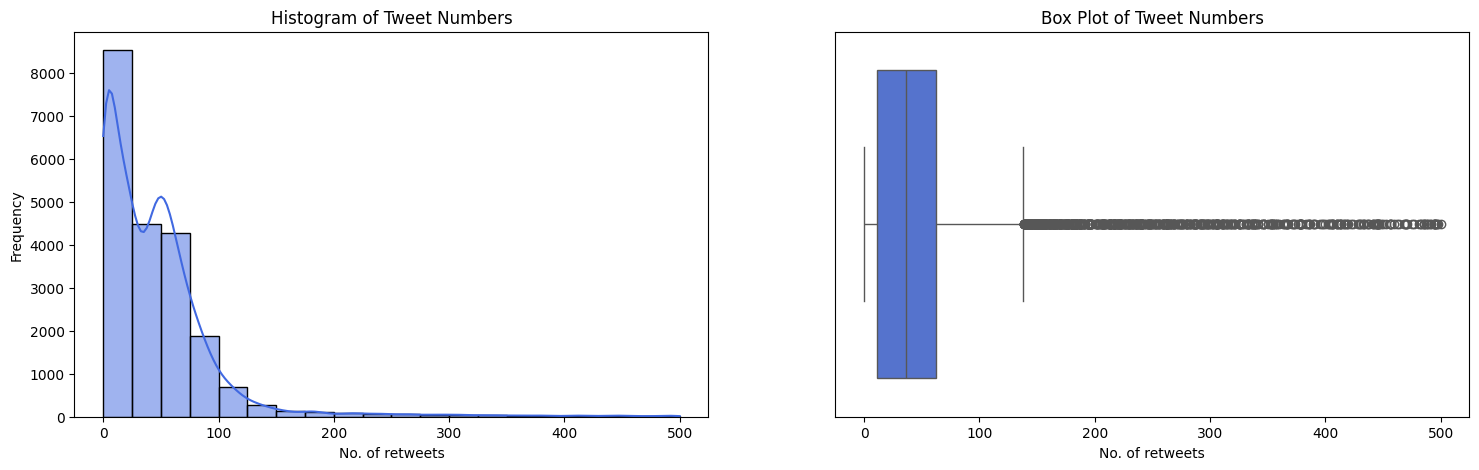


Graph shows most of the news articles have retweets in between 0-100 (19171)


In [ ]:
# Distribution of tweet_nums
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
sns.histplot(data=news, x='tweet_num', kde=True, bins=20, color='royalblue')
plt.title('Histogram of Tweet Numbers')
plt.xlabel('No. of retweets')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
sns.boxplot(data=news, x='tweet_num', color='royalblue')
plt.title('Box Plot of Tweet Numbers')
plt.xlabel('No. of retweets')
plt.yticks([])

plt.show()
print(f"\nGraph shows most of the news articles have retweets in between 0-100 ({news[news['tweet_num']<100].value_counts().sum()})")

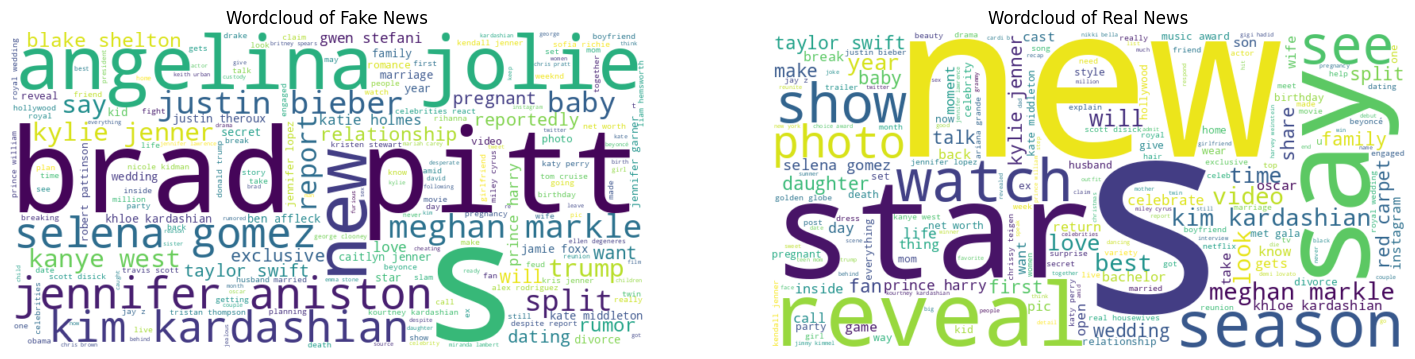

In [ ]:
# Wordclouds of Fake and Real news
news['title'] = news['title'].str.lower()
fake_news  = ' '.join(news[news['real'] == 0]['title'])
real_news = ' '.join(news[news['real'] == 1]['title'])

plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
wordcloud_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_news)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud of Fake News')

plt.subplot(1,2,2)
wordcloud_real = WordCloud(width=800, height=400, background_color='white').generate(real_news)
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud of Real News')

plt.show()

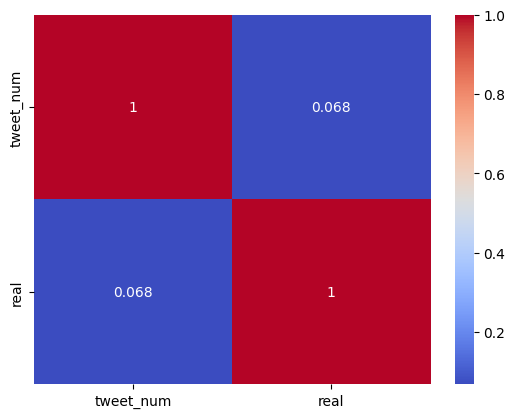

In [ ]:
# Correlation Analysis of tweet_num and real column
corr = news[['tweet_num','real']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Data Preprocessing
This section includes cleaning the values inside `title` and `source_domain`

In [ ]:
# Importing libraries
from tqdm import tqdm
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Cleaning up the source domains
news['source_domain'] = news['source_domain'].str.replace('www.', '', regex=False).str.rsplit(".").str[0]
display(news.sample(5))

,title,source_domain,tweet_num,real
15882,meghan king edmonds reveals the heartwarming n...,bravotv,2,1
935,112-year-old voters in north carolina?,pewtrusts,64,0
22377,the one outfit your zodiac sign should wear th...,cosmopolitan,95,1
19609,r. kelly sued by texas woman for sexual batter...,ajc,9,1
13710,"matthew perry actor, producer, director",tvguide,5,0


In [ ]:
# Cleaning up the title of the news
preprocessed_titles = []
text_data = news['title'].values

lemmatizer = WordNetLemmatizer()
stopwords = set(stopwords.words('english'))

for sentence in tqdm(text_data):
    sentence = re.sub(r'[^\w\s]', '', sentence) # removes punctuations and special characters
    tokens = word_tokenize(sentence.lower())
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    for word in lemmatized_tokens: # removes stopwords
        if word in stopwords:
            lemmatized_tokens.remove(word)
    final = ' '.join(lemmatized_tokens)
    preprocessed_titles.append(final)

news['title'] = preprocessed_titles
display(news.sample(5))

100%|██████████| 20822/20822 [00:06<00:00, 3279.92it/s]


,title,source_domain,tweet_num,real
22581,barack michelle obama bust dance move beyoncé ...,usatoday,0,1
18972,khloe kardashian wore bodysuit without pantsth...,longroom,52,1
2772,teen mom briana dejesus undergoes mommy makeover,popculture,72,1
21500,jennifer lopez alex rodriguez visit old stompi...,click2houston,11,0
13078,mindy project star ike barinholtz recovering b...,variety,39,1


In [ ]:
# Export clean dataset
with open(f"/content/FakeNewsNet_clean.csv", 'w') as fp:
    news.to_csv(fp, index=False)

### Pipeline and Train Preparation
This section includes:
- Splitting train and test data from the cleaned dataset
- Creating pipelines to automate the transformation of:
  - categorical data (`source_domain`) using `OneHotEncoder`
  - numerical data (`tweet_num`) using `StandardScaler`
  - textual data (`title`) using `TfidfVectorizer`
- And feeding the transformers to the `ColumnTransformer` (pipeline)

In [ ]:
# Importing libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
X = news[['title','source_domain','tweet_num']]
y = news['real']

display(X.head())
display(y.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .25, random_state=42)

,title,source_domain,tweet_num
0,kandi burruss explodes rape accusation real ho...,toofab,42
1,people choice award 2018 best red carpet look,today,0
2,sophia bush sends sweet birthday message one t...,etonline,63
3,colombian singer maluma spark rumour inappropr...,dailymail,20
4,gossip girl 10 year later upper east siders sh...,zerchoo,38


,real
0,1
1,1
2,1
3,1
4,1


In [ ]:
cat_features = ['source_domain']
num_features = ['tweet_num']
text_col = 'title'

# TODO: Replace OHE with LabelEncoder or Ord one as having too many unique cats causes dimensionality explosion
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # not using handle_unknow returns error that rare unknown categories are present..
])

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

text_vectorizer = Pipeline(steps=[
    ('vectorizer', TfidfVectorizer())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_transformer, cat_features),
    ('num', num_transformer, num_features),
    ('text', text_vectorizer, text_col)
])

### Model Training and Evaluation
This section includes training of four models:
- `Logistic Regression`:
  - Max Iterations: 1000
- `K-Nearest Neighbour`:
  - Nearest Neighbour (`k`): 5
- `Random Forest`:
  - No of Estimators (trees): 50
- `Feed-Forward Neural Network`:
  - Epochs: 60
  - Batch Size: 24

The models are evaluated based on the following metrics:
- `Accuracy`
- `Precision`
- `Recall`
- `F1 Score`
- `Train Loss` (FNN)

All the metrics of each models are then compared at the end of the trainign.

In [ ]:
# Importing libraries
from sklearn import set_config
set_config(display='diagram')

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [ ]:
eval_table = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

#### Logistic Regression

In [ ]:
# Train model
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['source_domain']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['tweet_num']),
                                                 ('text',
                                                  Pipeline(steps=[('vectorizer',
                                                                   TfidfVectorizer())]),
                                                  'title')])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
# Evaluation of model performance
print("Evaluation of Logistic Regression:")
y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {accuracy_lr:.5f} ({accuracy_lr * 100:.2f}%)")
print(f"\nClassification Report: \n{classification_report(y_test, y_pred_lr)}")

Evaluation of Logistic Regression:
Accuracy: 0.87073 (87.07%)

Classification Report: 
              precision    recall  f1-score   support

           0       0.84      0.51      0.64      1157
           1       0.88      0.97      0.92      4049

    accuracy                           0.87      5206
   macro avg       0.86      0.74      0.78      5206
weighted avg       0.87      0.87      0.86      5206



In [ ]:
lr_eval = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Accuracy': [f'{accuracy_lr * 100:.2f}%'],
    'Precision': [f'{precision_lr * 100:.2f}%'],
    'Recall': [f'{recall_lr * 100:.2f}%'],
    'F1 Score': [f'{f1_lr * 100:.2f}%']
})
display(lr_eval)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,87.07%,87.51%,97.26%,92.13%


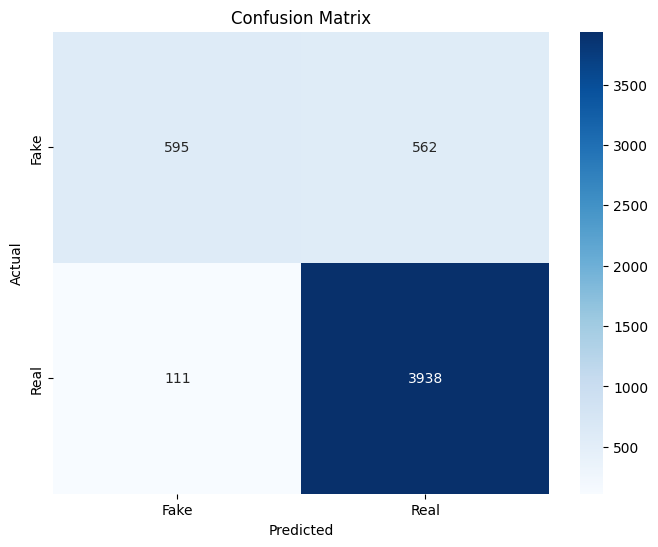

In [ ]:
# Confusion matrix representation
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### K-Nearest Neighbours

In [ ]:
knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['source_domain']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['tweet_num']),
                                                 ('text',
                                                  Pipeline(steps=[('vectorizer',
                                                                   TfidfVectorizer())]),
                                                  'title')])),
                ('classifier', KNeighborsClassifier())])

In [ ]:
# Evaluation of model performance
print("Evaluation of K-Nearest Neighbours:")
print("[k set to 5]")
y_pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Accuracy: {accuracy_knn:.5f} ({accuracy_knn * 100:.2f}%)")
print(f"\nClassification Report: \n{classification_report(y_test, y_pred_knn)}")

Evaluation of K-Nearest Neighbours:
[k set to 5]
Accuracy: 0.86362 (86.36%)

Classification Report: 
              precision    recall  f1-score   support

           0       0.75      0.58      0.66      1157
           1       0.89      0.94      0.91      4049

    accuracy                           0.86      5206
   macro avg       0.82      0.76      0.79      5206
weighted avg       0.86      0.86      0.86      5206



In [ ]:
knn_eval = pd.DataFrame({
    'Model': ['K-Nearest Neighbours'],
    'Accuracy': [f'{accuracy_knn * 100:.2f}%'],
    'Precision': [f'{precision_knn * 100:.2f}%'],
    'Recall': [f'{recall_knn * 100:.2f}%'],
    'F1 Score': [f'{f1_knn * 100:.2f}%']
})
display(knn_eval)

,Model,Accuracy,Precision,Recall,F1 Score
0,K-Nearest Neighbours,86.36%,88.82%,94.34%,91.50%


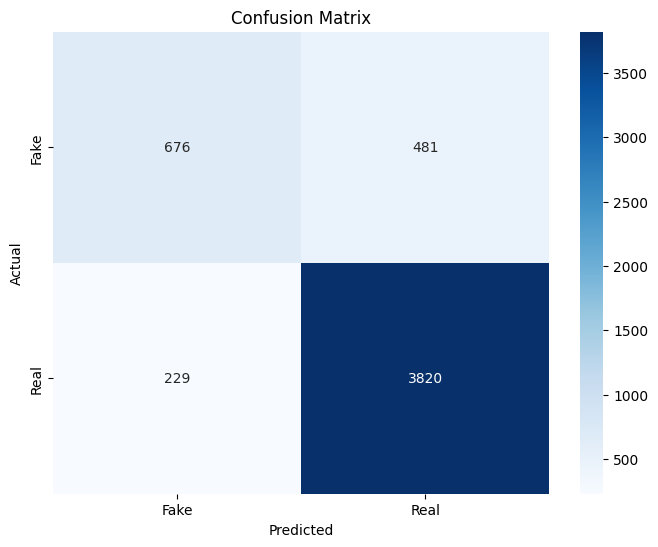

In [ ]:
# Confusion matrix representation
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Random Forest

In [ ]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=50, random_state=42))
])

rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['source_domain']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['tweet_num']),
                                                 ('text',
                                                  Pipeline(steps=[('vectorizer',
                                                                   TfidfVectorizer())]),
                                                  'title')])),
                ('classifier',
                 RandomForestClassifier(n_estimators=50, random_state=42))])

In [ ]:
# Evaluation of model performance
print("Evaluation of Random Forest:")
y_pred_rf = knn.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf:.5f} ({accuracy_rf * 100:.2f}%)")
print(f"\nClassification Report: \n{classification_report(y_test, y_pred_rf)}")

Evaluation of Random Forest:
Accuracy: 0.86362 (86.36%)

Classification Report: 
              precision    recall  f1-score   support

           0       0.75      0.58      0.66      1157
           1       0.89      0.94      0.91      4049

    accuracy                           0.86      5206
   macro avg       0.82      0.76      0.79      5206
weighted avg       0.86      0.86      0.86      5206



In [ ]:
rf_eval = pd.DataFrame({
    'Model': ['Random Forest'],
    'Accuracy': [f'{accuracy_rf * 100:.2f}%'],
    'Precision': [f'{precision_rf * 100:.2f}%'],
    'Recall': [f'{recall_rf * 100:.2f}%'],
    'F1 Score': [f'{f1_rf * 100:.2f}%']
})
display(rf_eval)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,86.36%,88.82%,94.34%,91.50%


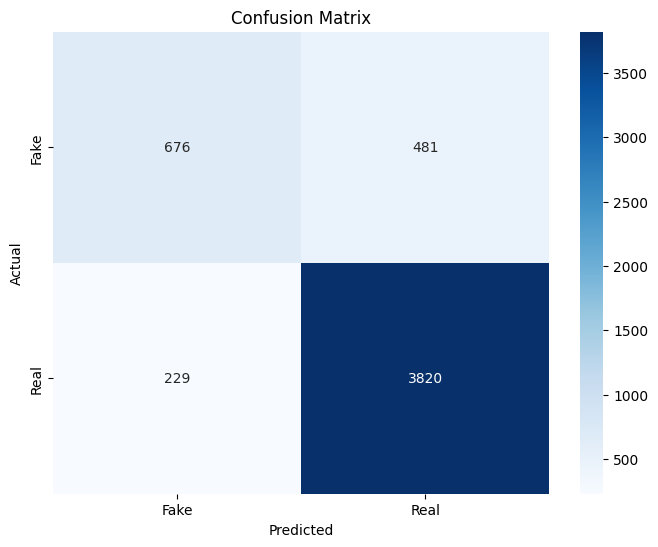

In [ ]:
# Confusion matrix representation
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Feedforward Neural Network

In [ ]:
set_config(display='text')

# TODO: Preprocess the data manually for the Keras model since sklearn.Pipeline isnt compatible with scikeras
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

fnn = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

fnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = fnn.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8206 - loss: 0.4272 - val_accuracy: 0.8780 - val_loss: 0.3043
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9156 - loss: 0.2197 - val_accuracy: 0.8790 - val_loss: 0.2948
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9504 - loss: 0.1322 - val_accuracy: 0.8768 - val_loss: 0.3245
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9741 - loss: 0.0798 - val_accuracy: 0.8643 - val_loss: 0.3919
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9830 - loss: 0.0526 - val_accuracy: 0.8569 - val_loss: 0.4498
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9902 - loss: 0.0326 - val_accuracy: 0.8560 - val_loss: 0.5063
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9938 - loss: 0.0211 - val_accuracy: 0.8505 - val_loss: 0.5664
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9962 - loss: 0.0146 - val_accu

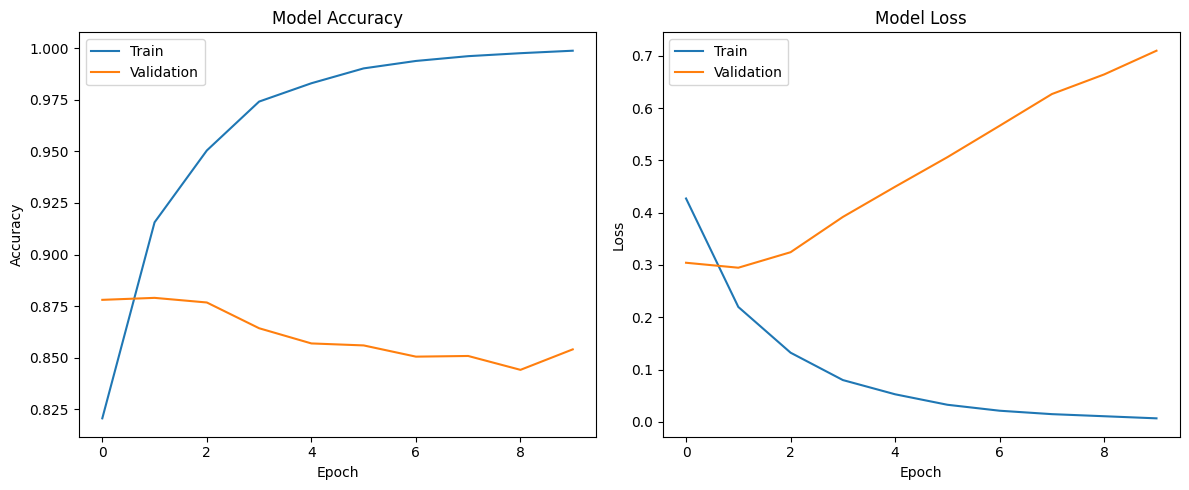

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

In [ ]:
# Evaluation of model performance
print("Evaluation of Feed-Forward Neural Network:")

# X_test_transformed was created in the training cell
y_pred_fnn = (fnn.predict(X_test) > 0.5).astype("int32")
loss_fnn, accuracy_fnn = fnn.evaluate(X_test, y_test, verbose=0)
precision_fnn = precision_score(y_test, y_pred_fnn)
recall_fnn = recall_score(y_test, y_pred_fnn)
f1_fnn = f1_score(y_test, y_pred_fnn)

print(f"Test Loss: {loss_fnn:.5f}")
print(f"Accuracy Score: {accuracy_fnn:.5f} ({accuracy_fnn * 100:.2f}%)")
print(f"\nClassification Report: \n{classification_report(y_test, y_pred_fnn)}")

Evaluation of Feed-Forward Neural Network:
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Loss: 0.28780
Accuracy Score: 0.88360 (88.36%)

Classification Report: 
              precision    recall  f1-score   support

           0       0.78      0.66      0.72      1157
           1       0.91      0.95      0.93      4049

    accuracy                           0.88      5206
   macro avg       0.84      0.80      0.82      5206
weighted avg       0.88      0.88      0.88      5206



In [ ]:
fnn_eval = pd.DataFrame({
    'Model': ['Feed-Forward Neural Network'],
    'Accuracy': [f'{accuracy_fnn * 100:.2f}%'],
    'Precision': [f'{precision_fnn * 100:.2f}%'],
    'Recall': [f'{recall_fnn * 100:.2f}%'],
    'F1 Score': [f'{f1_fnn * 100:.2f}%']
})
display(fnn_eval)

,Model,Accuracy,Precision,Recall,F1 Score
0,Feed-Forward Neural Network,88.36%,90.71%,94.74%,92.68%


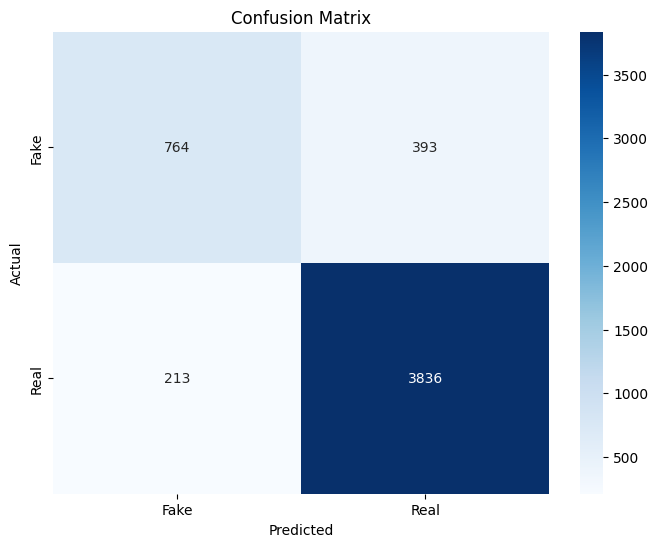

In [ ]:
# Confusion matrix representation
cm = confusion_matrix(y_test, y_pred_fnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Comparision of Model Performance

In [ ]:
final_eval_table = pd.concat([eval_table,lr_eval,knn_eval,rf_eval,fnn_eval], axis='rows') # the code runs fine but dunno why it shows this error
final_eval_table.reset_index(drop=True, inplace=True)

print("The comparision of performance of all four models:")
display(final_eval_table)

The comparision of performance of all four models:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,87.07%,87.51%,97.26%,92.13%
1,K-Nearest Neighbours,86.36%,88.82%,94.34%,91.50%
2,Random Forest,86.36%,88.82%,94.34%,91.50%
3,Feed-Forward Neural Network,88.36%,90.71%,94.74%,92.68%


### Export models to a file

In [ ]:
# Import libraries
import joblib # faster than pickle for storing numpy arrays
from tensorflow.keras.models import load_model

In [ ]:
# Extraxting just model object from the pipeline
lr_model = lr.named_steps['classifier']
knn_model = knn.named_steps['classifier']
rf_model = rf.named_steps['classifier']

In [ ]:
# Exporting models to respective files
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(knn_model, 'knn_model.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(fnn, 'fnn_model.pkl')

['fnn_model.pkl']

In [ ]:
# Test check
# TODO: Export the preprocessor to transform the input dataset in the deployment app
imported_lr = joblib.load('lr_model.pkl')
imported_knn = joblib.load('knn_model.pkl')
imported_rf = joblib.load('rf_model.pkl')
imported_fnn = joblib.load('fnn_model.pkl')

y_pred_lr_sample = imported_lr.predict(X_test)
y_pred_knn_sample = imported_knn.predict(X_test)
y_pred_rf_sample = imported_rf.predict(X_test)
y_pred_fnn_sample = (imported_fnn.predict(X_test) > 0.5).astype("int32")

print(f"Accuracy of LR: {accuracy_score(y_test, y_pred_lr_sample) * 100:.2f}%")
print(f"Accuracy of KNN: {accuracy_score(y_test, y_pred_knn_sample) * 100:.2f}%")
print(f"Accuracy of RF: {accuracy_score(y_test, y_pred_rf_sample) * 100:.2f}%")
print(f"Accuracy of FNN: {accuracy_score(y_test, y_pred_fnn_sample) * 100:.2f}%")

163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Accuracy of LR: 87.07%
Accuracy of KNN: 86.36%
Accuracy of RF: 88.19%
Accuracy of FNN: 88.36%
